# House Price Prediction using Machine Learning

## Introduction
This project focuses on predicting house prices using Machine Learning techniques. 
We use features like area, number of bedrooms, bathrooms, floors, and view to estimate the price of a house.

Both Linear Regression and Neural Network models are used for prediction.

In [1]:
## Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Loading the Dataset
df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
# Data Understanding
# We analyze the dataset structure, data types, and statistical summary.
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [4]:
# Data Cleaning
# We check for missing values and remove them to ensure clean data.
df.isnull().sum()
df = df.dropna()

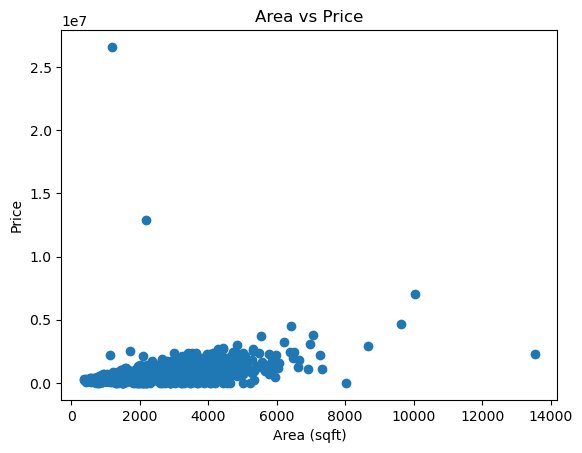

In [5]:
# Data Visualization
# We visualize the relationship between area and house price.
plt.scatter(df['sqft_living'], df['price'])
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [6]:
# Feature Selection
# We select relevant features that affect house price.
X = df[['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'view']]
y = df['price']

## Splitting Data
We split the dataset into training and testing sets.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression Model
We train a Linear Regression model for prediction.

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction using Linear Regression

In [9]:
y_pred = model.predict(X_test)

## Model Evaluation
We evaluate the model using Mean Squared Error (MSE) and R2 Score.

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

print("R2 Score:", r2_score(y_test, y_pred))

MSE: 989906638552.2268
R2 Score: 0.02935707111737551


## Actual vs Predicted Graph

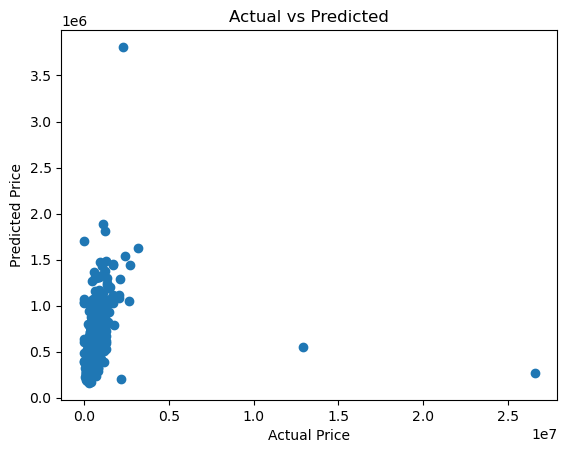

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [12]:
# Saving Results
output = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

output.to_csv("output.csv", index=False)

# NEURAL NETWORK

## Feature Scaling
Scaling is applied to improve Neural Network performance.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Neural Network Model
A deep learning model is used for improved prediction accuracy.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_nn = Sequential()

model_nn.add(Input(shape=(X.shape[1],)))
model_nn.add(Dense(64, activation='relu'))
model_nn.add(Dense(32, activation='relu'))
model_nn.add(Dense(1))

model_nn.compile(optimizer='adam', loss='mse')

## Training Neural Network

In [15]:
model_nn.fit(X_train_scaled, y_train, epochs=30, batch_size=8)

Epoch 1/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 438728130560.0000
Epoch 2/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 435553763328.0000
Epoch 3/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 424557543424.0000
Epoch 4/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 403247529984.0000
Epoch 5/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 372499054592.0000
Epoch 6/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 332893650944.0000
Epoch 7/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 288530825216.0000
Epoch 8/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 243476578304.0000
Epoch 9/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 202063937536.0000
Epoch 10/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 166671777792.0000
Epoch 11/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 139177312256.0000
Epoch 12/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 120260870144.0000
Epoch 13/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 

## Prediction using Neural Network

In [16]:
y_pred_nn = model_nn.predict(X_test_scaled)
y_pred_nn = y_pred_nn.flatten()

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


## Neural Network Evaluation

In [17]:
mse_nn = mean_squared_error(y_test, y_pred_nn)

print("Linear Regression MSE:", mse)
print("Neural Network MSE:", mse_nn)

Linear Regression MSE: 989906638552.2268
Neural Network MSE: 994037777998.1824


## Graphs 

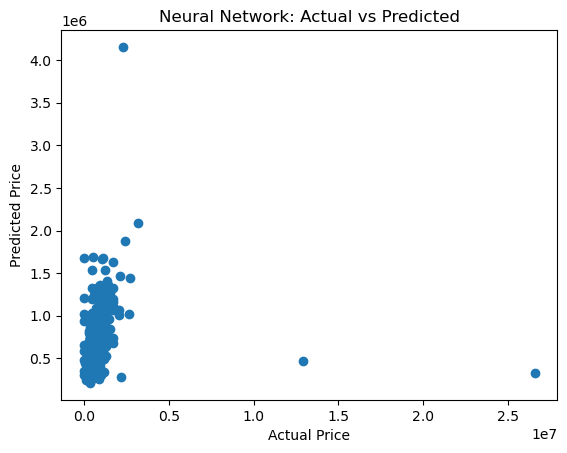

In [18]:
plt.scatter(y_test, y_pred_nn)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Neural Network: Actual vs Predicted")
plt.show()

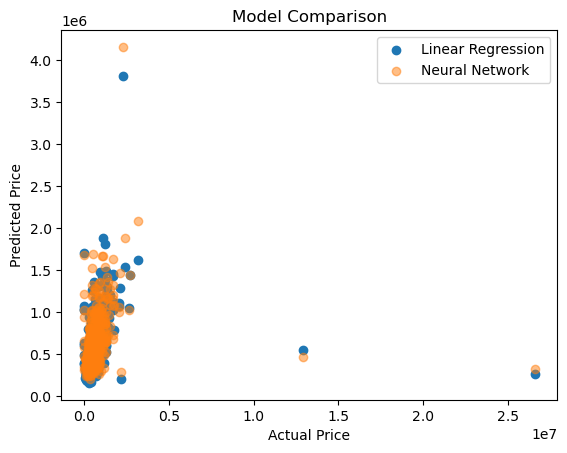

In [19]:
plt.scatter(y_test, y_pred, label="Linear Regression")
plt.scatter(y_test, y_pred_nn, label="Neural Network", alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Model Comparison")
plt.legend()
plt.show()

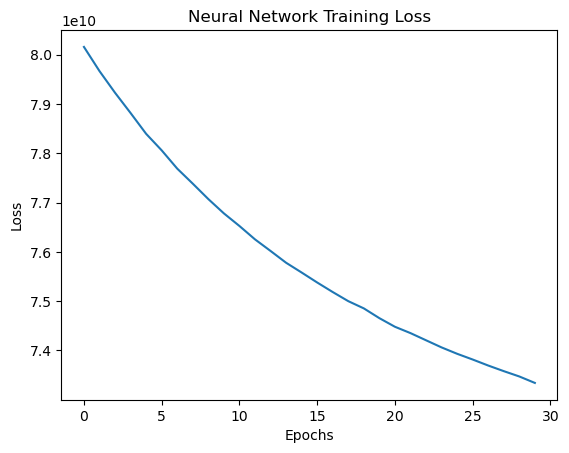

In [20]:
history = model_nn.fit(
    X_train_scaled, 
    y_train, 
    epochs=30, 
    batch_size=8,
    verbose=0
)

plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")
plt.show()

In [21]:
## Custom Prediction
sample = pd.DataFrame([[2000, 3, 2, 2, 1]],
columns=['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'view'])

prediction = model.predict(sample)
print("Predicted Price:", prediction[0])

Predicted Price: 598055.4966957967


## Conclusion
The project successfully predicts house prices using both Linear Regression and Neural Network models. 
The Neural Network model performs better after applying feature scaling.